In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
print("torch version:", torch.__version__)

torch version: 2.9.1


## Data Setup

- Prompt: `"I love paris"`
- 3 outputs, reward only at the last token
- state = prompt + tokens generated so far

| step | state | reward |
|------|-------|--------|
| s0 | I love paris | 0 |
| s1 | I love paris \| I | 0 |
| s2 | I love paris \| I also | 0 |
| s3 | I love paris \| I also love | 0 |
| s4 | terminal (paris generated) | **1.1** |

In [7]:
vocab = {
    "<pad>": 0, "I": 1, "love": 2, "paris": 3,
    "also": 4, "great": 5, "what": 6, "else": 7,
    "you": 8, "nice": 9, "to": 10, "meet": 11,
}
VOCAB_SIZE = len(vocab)

trajectories = [
    {
        "name": "I also love paris",
        "tokens": ["I", "also", "love", "paris"],
        "states": [
            [1, 2, 3],              # s0: prompt only
            [1, 2, 3, 1],           # s1: + I
            [1, 2, 3, 1, 4],        # s2: + also
            [1, 2, 3, 1, 4, 2],     # s3: + love
            [1, 2, 3, 1, 4, 2, 3],  # s4: terminal
        ],
        "rewards": [0.0, 0.0, 0.0, 1.1],
    },
    {
        "name": "great what else you",
        "tokens": ["great", "what", "else", "you"],
        "states": [
            [1, 2, 3],
            [1, 2, 3, 5],
            [1, 2, 3, 5, 6],
            [1, 2, 3, 5, 6, 7],
            [1, 2, 3, 5, 6, 7, 8],
        ],
        "rewards": [0.0, 0.0, 0.0, 0.9],
    },
    {
        "name": "nice to meet you",
        "tokens": ["nice", "to", "meet", "you"],
        "states": [
            [1, 2, 3],
            [1, 2, 3, 9],
            [1, 2, 3, 9, 10],
            [1, 2, 3, 9, 10, 11],
            [1, 2, 3, 9, 10, 11, 8],
        ],
        "rewards": [0.0, 0.0, 0.0, 0.1],
    },
]

print("Trajectories:", [t["name"] for t in trajectories])
print("Rewards:", [t["rewards"] for t in trajectories])

for traj in trajectories:
    for t, token in enumerate(traj["tokens"]):
        print(t, token)
    print('\n')
    


Trajectories: ['I also love paris', 'great what else you', 'nice to meet you']
Rewards: [[0.0, 0.0, 0.0, 1.1], [0.0, 0.0, 0.0, 0.9], [0.0, 0.0, 0.0, 0.1]]
0 I
1 also
2 love
3 paris


0 great
1 what
2 else
3 you


0 nice
1 to
2 meet
3 you




## Critic Network

```
Input: token id sequence (current state as text)
  -> Embedding: vocab_size -> 16 dims per token
  -> Mean Pooling: average all token embeddings -> 1x16
  -> MLP: 16 -> 32 -> 1
Output: V(s), a single scalar
```

> Note: in real LLM PPO, embeddings come from pretrained LLM (not random)

In [18]:
class Critic(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_dim=32):
        super().__init__()
        # Maps each token id to an embed_dim vector (trainable)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # MLP: maps averaged embedding to scalar V(s)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, token_ids):
        x = torch.tensor(token_ids).unsqueeze(0)  # (1, seq_len)
        emb = self.embedding(x).mean(dim=1)        # (1, embed_dim)
        return self.mlp(emb).squeeze()             # scalar

# Quick test
test_critic = Critic(VOCAB_SIZE)

print("V(s0) initial (random):", test_critic([1]).item())
print("V(s0) initial (random):", test_critic([1,2]).item())
print("V(s0) initial (random):", test_critic([1,2,3]).item())


V(s0) initial (random): 0.05824695900082588
V(s0) initial (random): 0.058470819145441055
V(s0) initial (random): 0.09013202041387558


In [17]:
def print_v_table(critic, label=""):
    sep = "-" * 60
    print(f"\n{sep}")
    print(f"  {label}")
    print(f"{sep}")
    print(f"  {'Trajectory':<22} {'token':<8} {'V(s_t)':>8}    reward")
    print(f"  {sep}")
    for traj in trajectories:
        for t, token in enumerate(traj["tokens"]):
            with torch.no_grad():
                v = critic(traj["states"][t]).item()
            r = traj["rewards"][t]
            marker = "  <- reward here" if r > 0 else ""
            print(f"  {traj['name']:<22} {token:<8} {v:>8.4f}    {r}{marker}")
        print()

## Train Critic

Each training step:
1. Critic predicts `V(s_t)`
2. V(S_t): is the value esitmation of current state (if we follow the current policy - CURRENT P).
3. Compute TD target:
   - Last step: `target = r_T` (real reward enters here)
   - Middle steps: `target = gamma * V(s_{t+1})` (bootstrapping)
4. `loss = (V(s_t) - target)^2`
5. Backprop, update Critic params

**Watch how reward 1.1 propagates backward epoch by epoch**

In [19]:
def train_critic(n_epochs=500, gamma=1.0, lr=0.01):
    # Initialize Critic with random params
    critic = Critic(VOCAB_SIZE)

    # Adam optimizer — only updates Critic parameters
    optimizer = optim.Adam(critic.parameters(), lr=lr)

    print_v_table(critic, "Before training (V values ~ 0)")

    for epoch in range(n_epochs):
        epoch_loss = 0.0  # accumulate loss across all steps this epoch

        for traj in trajectories:
            states  = traj["states"]   # [s0, s1, s2, s3, s4(terminal)]
            rewards = traj["rewards"]  # [0, 0, 0, 1.1]
            n_steps = len(rewards)     # 4

            for t in range(n_steps):
                # Is this the last generated token?
                is_terminal = (t == n_steps - 1)

                # Critic predicts V(s_t) — requires_grad=True
                v_t = critic(states[t])

                # ── Compute TD target (the "correct answer") ──
                if is_terminal:
                    # Last step: V(s_terminal)=0, so target = r_T
                    # Real reward enters the training signal here
                    td_target = torch.tensor(rewards[t], dtype=torch.float32)
                else:
                    # Middle step: r_t=0, target = gamma * V(s_{t+1})
                    # no_grad: V(s_next) is reference only, not part of gradient
                    # (prevents gradient flowing through target -> unstable training)
                    with torch.no_grad():
                        v_next = critic(states[t + 1])
                    td_target = rewards[t] + gamma * v_next

                # ── Critic loss: pull V(s_t) toward td_target ──
                # MSE: (predicted - target)^2
                loss = (v_t - td_target) ** 2

                # Clear previous gradients (PyTorch accumulates by default)
                optimizer.zero_grad()

                # Backprop: compute gradients of loss w.r.t. all Critic params
                loss.backward()

                # Update Critic params using Adam
                optimizer.step()

                epoch_loss += loss.item()

        # Print V values at key epochs to observe reward propagation
        if epoch + 1 in (1, 10, 50, 100, 200, 500):
            print_v_table(critic, f"Epoch {epoch+1:4d}  Loss={epoch_loss:.4f}")

    return critic


critic = train_critic(n_epochs=500, gamma=1.0, lr=0.01)


------------------------------------------------------------
  Before training (V values ~ 0)
------------------------------------------------------------
  Trajectory             token      V(s_t)    reward
  ------------------------------------------------------------
  I also love paris      I          0.2968    0.0
  I also love paris      also       0.3740    0.0
  I also love paris      love       0.3137    0.0
  I also love paris      paris      0.2761    1.1  <- reward here

  great what else you    great      0.2968    0.0
  great what else you    what       0.2413    0.0
  great what else you    else       0.1812    0.0
  great what else you    you        0.1694    0.9  <- reward here

  nice to meet you       nice       0.2968    0.0
  nice to meet you       to         0.3142    0.0
  nice to meet you       meet       0.3661    0.0
  nice to meet you       you        0.3716    0.1  <- reward here


------------------------------------------------------------
  Epoch    1  L

## Compute GAE with Trained Critic

```
delta_t = r_t + gamma * V(s_{t+1}) - V(s_t)    <- TD error
A_t = delta_t + gamma*lam * A_{t+1}              <- GAE (backward accumulation)
```

- `delta_t > 0`: this step was better than Critic expected (surprise)
- `delta_t < 0`: worse than expected
- `A_t`: cumulative surprise from step t onward

delta_t vs A_t:

delta_t: this step ws how much better than critic expected (surprise)

A_t: the surpise from this step + the total surprise from all following steps （discounted by lam）

A_0 = delta_0 + λ·delta_1 + λ²·delta_2 + λ³·delta_3


In [21]:
def compute_gae(critic, gamma=1.0, lam=0.95):
    print("\n" + "=" * 60)
    print("  GAE Results (after training)")
    print("=" * 60)

    for traj in trajectories:
        states  = traj["states"]
        rewards = traj["rewards"]
        tokens  = traj["tokens"]
        n = len(rewards)

        # Get V for each state, V(terminal)=0
        V = []
        for t in range(n):
            with torch.no_grad():
                V.append(critic(states[t]).item())
        V.append(0.0)  # V(s_terminal) = 0

        # TD error: delta_t = r_t + gamma*V(s_{t+1}) - V(s_t)
        deltas = [rewards[t] + gamma * V[t+1] - V[t] for t in range(n)]

        # GAE: accumulate backwards (must go backward since A_t depends on A_{t+1})
        advantages = [0.0] * n
        advantages[-1] = deltas[-1]
        for t in reversed(range(n - 1)):
            advantages[t] = deltas[t] + gamma * lam * advantages[t + 1]

        print(f"\n  Trajectory: {traj['name']}")
        print(f"  {'token':<8} {'V(s_t)':>9} {'delta_t':>9} {'Advantage':>12}")
        print(f"  {'-'*42}")
        for t, token in enumerate(tokens):
            print(f"  {token:<8} {V[t]:>9.4f} {deltas[t]:>+9.4f} {advantages[t]:>+12.4f}")


compute_gae(critic)


  GAE Results (after training)

  Trajectory: I also love paris
  token       V(s_t)   delta_t    Advantage
  ------------------------------------------
  I           0.6789   +0.4005      +0.4192
  also        1.0794   +0.0128      +0.0197
  love        1.0922   -0.0026      +0.0072
  paris       1.0896   +0.0104      +0.0104

  Trajectory: great what else you
  token       V(s_t)   delta_t    Advantage
  ------------------------------------------
  great       0.6789   +0.1941      +0.2174
  what        0.8730   +0.0015      +0.0245
  else        0.8746   +0.0002      +0.0242
  you         0.8748   +0.0252      +0.0252

  Trajectory: nice to meet you
  token       V(s_t)   delta_t    Advantage
  ------------------------------------------
  nice        0.6789   -0.5806      -0.5792
  to          0.0983   -0.0001      +0.0015
  meet        0.0982   -0.0007      +0.0017
  you         0.0975   +0.0025      +0.0025


## Visualize: V(s) Propagation Over Training

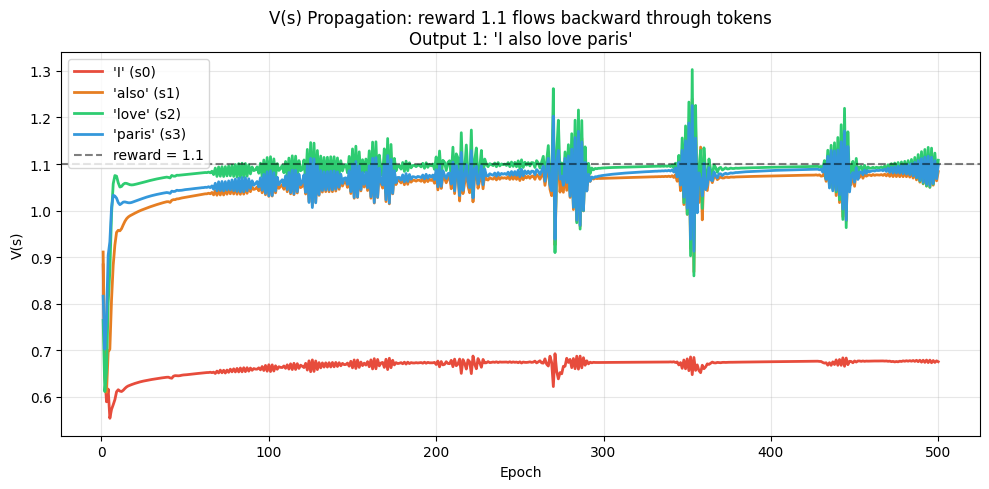

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_v_propagation(n_epochs=500, gamma=1.0, lr=0.01):
    c = Critic(VOCAB_SIZE)
    opt = optim.Adam(c.parameters(), lr=lr)
    traj1 = trajectories[0]
    history = {t: [] for t in range(4)}
    epoch_list = []

    for epoch in range(n_epochs):
        for traj in trajectories:
            states = traj["states"]
            rewards = traj["rewards"]
            for t in range(len(rewards)):
                is_terminal = (t == len(rewards) - 1)
                v_t = c(states[t])
                if is_terminal:
                    td_target = torch.tensor(rewards[t], dtype=torch.float32)
                else:
                    with torch.no_grad():
                        v_next = c(states[t + 1])
                    td_target = rewards[t] + gamma * v_next
                loss = (v_t - td_target) ** 2
                opt.zero_grad()
                loss.backward()
                opt.step()

        epoch_list.append(epoch + 1)
        for t in range(4):
            with torch.no_grad():
                history[t].append(c(traj1["states"][t]).item())

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"]
    labels = ["'I' (s0)", "'also' (s1)", "'love' (s2)", "'paris' (s3)"]
    for t in range(4):
        ax.plot(epoch_list, history[t], color=colors[t], label=labels[t], linewidth=2)
    ax.axhline(y=1.1, color="black", linestyle="--", alpha=0.5, label="reward = 1.1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("V(s)")
    ax.set_title("V(s) Propagation: reward 1.1 flows backward through tokens\nOutput 1: 'I also love paris'")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_v_propagation()

## Final V(s) Comparison Across 3 Trajectories

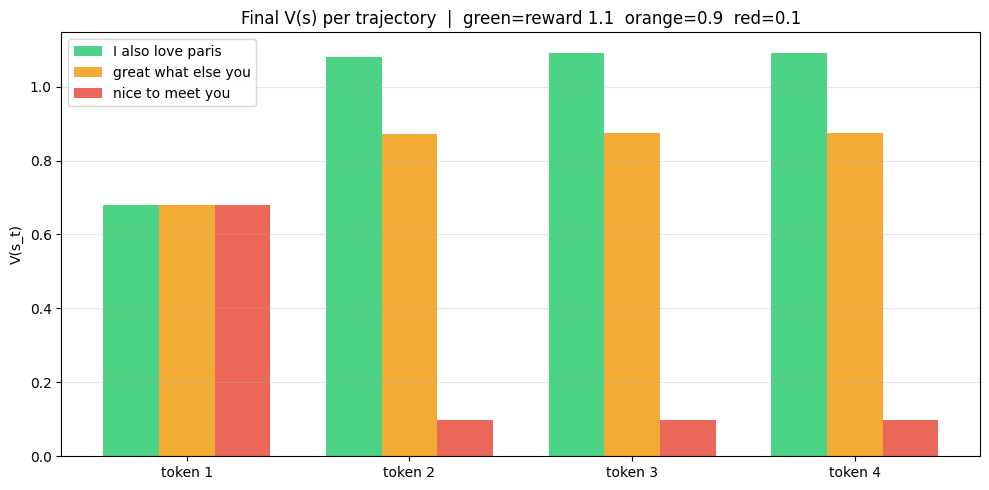


Key observations:
  1. High reward trajectory (1.1): all tokens have high V
  2. Low reward trajectory (0.1): all tokens have low V
  3. Critic learned which path leads to good reward
  4. GAE delta is large where Critic was surprised (not where reward was)


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
x = np.arange(4)
width = 0.25

for i, traj in enumerate(trajectories):
    V_vals = []
    for t in range(4):
        with torch.no_grad():
            V_vals.append(critic(traj["states"][t]).item())
    ax.bar(x + i * width, V_vals, width, label=traj["name"], color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(["token 1", "token 2", "token 3", "token 4"])
ax.set_ylabel("V(s_t)")
ax.set_title("Final V(s) per trajectory  |  green=reward 1.1  orange=0.9  red=0.1")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  1. High reward trajectory (1.1): all tokens have high V")
print("  2. Low reward trajectory (0.1): all tokens have low V")
print("  3. Critic learned which path leads to good reward")
print("  4. GAE delta is large where Critic was surprised (not where reward was)")